<a href="https://colab.research.google.com/github/carocarolina/fdm-laplace-3d/blob/main/laplace_caja_proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Resolución Numérica y Analítica de la Ecuación de Laplace 3D

Este proyecto aborda la resolución de la **Ecuación de Laplace en 3D** ($\nabla^2 V = 0$) en un dominio cúbico de dimensiones $L_x \times L_y \times L_z = 5 \times 5 \times 5$.

El objetivo es comparar la precisión y el rendimiento computacional tomando un enfoque analítico (Fourier en 3D) y posteriormente numérico (Aproximación con el Método de Diferencias Finitas)

Se evalúa el error global en norma $L_2$ y el tiempo de cómputo para diferentes resoluciones de malla ($N = 30, 50, 70$).

Se imponen condiciones de borde de Dirichlet:
- Potencial $V = V_0 = 5\,\text{V}$ en la cara inferior ($Z = 0$).
- Potencial $V = 0\,\text{V}$ en el resto de las paredes del dominio.

In [10]:
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scipy.sparse.linalg as spla

# Configuración de parámetros del dominio
lx = ly = lz = 5.0
V0 = 5.0
n_nodos = [30, 50, 70]
resultados = []

for n in n_nodos:
  nx = ny = nz = n
  N = nx * ny * nz
  dx = lx / (nx - 1)
  dy = ly / (ny - 1)
  dz = lz / (nz - 1)

  # Coordenadas 1D
  x = np.linspace(0, lx, nx)
  y = np.linspace(0, ly, ny)
  z = np.linspace(0, lz, nz)

  # Malla 3D de coordenadas
  X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

  # Identificación de bordes en formato 3D y 1D
  borde_3d = (
      (X == 0) | (X == lx) | (Y == 0) | (Y == ly) | (Z == 0) | (Z == lz)
  )
  base_3d = Z == 0
  interiores_3d = ~borde_3d

  es_borde = borde_3d.ravel()
  es_base = base_3d.ravel()

  # Matriz Dispersa
  px = 1 / (dx * dx)
  py = 1 / (dy * dy)
  pz = 1 / (dz * dz)
  pc = -(2 * px) - (2 * py) - (2 * pz)

  diag_c = np.where(es_borde, 1.0, pc)

  diag_x_neg = np.where(es_borde[1:], 0.0, px)
  diag_x_pos = np.where(es_borde[:-1], 0.0, px)

  diag_y_neg = np.where(es_borde[nx:], 0.0, py)
  diag_y_pos = np.where(es_borde[:-nx], 0.0, py)

  diag_z_neg = np.where(es_borde[nx * ny :], 0.0, pz)
  diag_z_pos = np.where(es_borde[: -nx * ny], 0.0, pz)

  A = sp.diags(
      [
          diag_z_neg,
          diag_y_neg,
          diag_x_neg,
          diag_c,
          diag_x_pos,
          diag_y_pos,
          diag_z_pos,
      ],
      [-(nx * ny), -nx, -1, 0, 1, nx, (nx * ny)],
      format='csr',
  )

  # Vector de términos independientes
  b = np.zeros(N)
  b[es_base] = V0

  # Resolución Numérica
  t0 = time.perf_counter()
  V_num, info = spla.bicgstab(A, b, rtol=1e-6)
  tf = time.perf_counter()
  tiempo_transcurrido = tf - t0

  # Solución con Fourier
  V_analitico = np.zeros((nx, ny, nz))
  N_terminos = 30

  for m_term in range(1, N_terminos, 2):
    for n_term in range(1, N_terminos, 2):
      C_mn = (16 * V0) / ((np.pi**2) * m_term * n_term)
      gamma_mn = np.pi * np.sqrt(
          (m_term * lz / lx) ** 2 + (n_term * lz / ly) ** 2
      )

      seno_x = np.sin(m_term * np.pi * X / lx)
      seno_y = np.sin(n_term * np.pi * Y / ly)

      # sinh
      degradado_z = np.sinh(gamma_mn * (lz - Z) / lz) / np.sinh(gamma_mn)

      V_analitico += C_mn * seno_x * seno_y * degradado_z

  # Error
  V_num_3D = V_num.reshape((nx, ny, nz))

  error_L2 = np.sqrt(
      np.mean((V_num_3D[interiores_3d] - V_analitico[interiores_3d]) ** 2)
  )

  resultados.append({
      'Nodos_3D': f'{n}x{n}x{n}',
      'Total_Nodos': N,
      'Paso_h': dx,
      'Tiempo_s': tiempo_transcurrido,
      'Error_L2_RMSE': error_L2,
  })

  print(
      f'Nodos {n}x{n}x{n} procesados en {tiempo_transcurrido:.4f}s | RMSE'
      f' Interior: {error_L2:.6e}'
  )

df_resultados = pd.DataFrame(resultados)
print('\n== RESULTADOS ==')
display(df_resultados)

Nodos 30x30x30 procesados en 0.0367s | RMSE Interior: 1.240824e+00
Nodos 50x50x50 procesados en 0.0427s | RMSE Interior: 1.321447e+00
Nodos 70x70x70 procesados en 0.0245s | RMSE Interior: 1.357949e+00

== RESULTADOS ==


,Nodos_3D,Total_Nodos,Paso_h,Tiempo_s,Error_L2_RMSE
0,30x30x30,27000,0.172414,0.036658,1.240824
1,50x50x50,125000,0.102041,0.042695,1.321447
2,70x70x70,343000,0.072464,0.024500,1.357949


Curva de Convergencia del Error y Tiempo de Cómputo

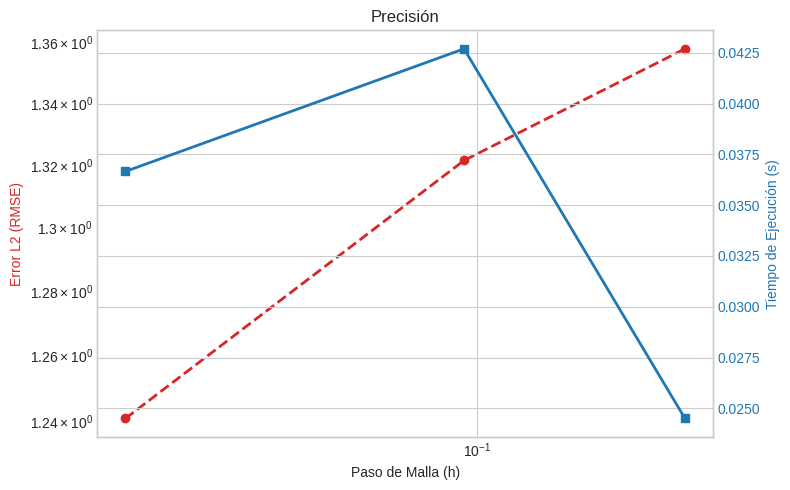

In [11]:
fig, ax1 = plt.subplots(figsize=(8, 5))

color = 'tab:red'
ax1.set_xlabel('Paso de Malla (h)')
ax1.set_ylabel('Error L2 (RMSE)', color=color)
ax1.plot(
    df_resultados['Paso_h'],
    df_resultados['Error_L2_RMSE'],
    'o--',
    color=color,
    linewidth=2,
    label='Error L2',
)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.invert_xaxis()

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Tiempo de Ejecución (s)', color=color)
ax2.plot(
    df_resultados['Paso_h'],
    df_resultados['Tiempo_s'],
    's-',
    color=color,
    linewidth=2,
    label='Tiempo',
)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Precisión')
fig.tight_layout()
plt.show()

Perfil de Potencial Electrostático / Térmico (Corte en plano central $Y = L_y / 2$)

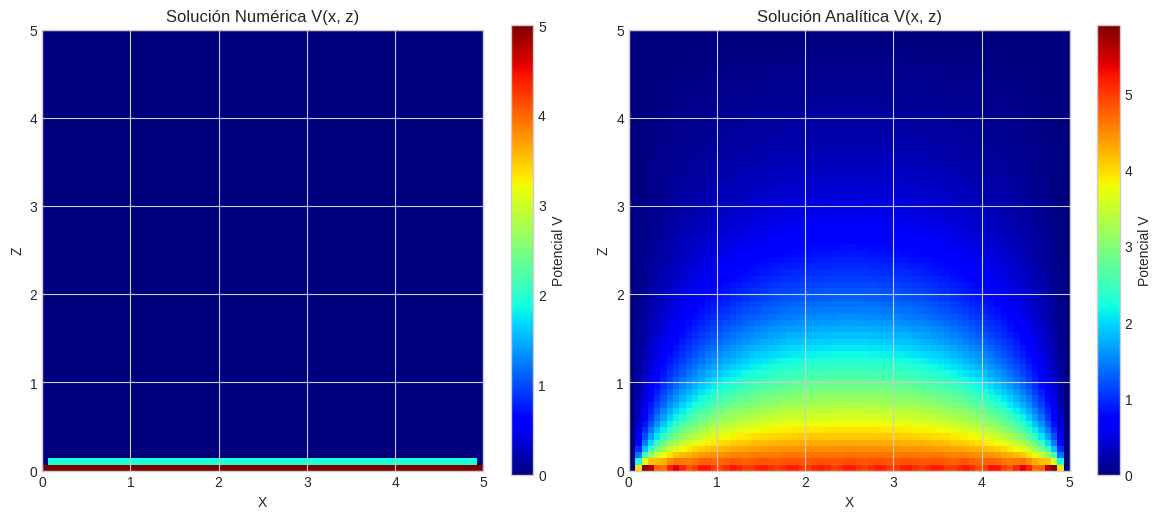

In [12]:
# Visualización del mapa de calor en la última resolución calculada
corte_y = ny // 2

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

im1 = axs[0].imshow(
    V_num_3D[:, corte_y, :].T,
    origin='lower',
    extent=[0, lx, 0, lz],
    cmap='jet',
)
axs[0].set_title('Solución Numérica V(x, z)')
axs[0].set_xlabel('X')
axs[0].set_ylabel('Z')
fig.colorbar(im1, ax=axs[0], label='Potencial V')

im2 = axs[1].imshow(
    V_analitico[:, corte_y, :].T,
    origin='lower',
    extent=[0, lx, 0, lz],
    cmap='jet',
)
axs[1].set_title('Solución Analítica V(x, z)')
axs[1].set_xlabel('X')
axs[1].set_ylabel('Z')
fig.colorbar(im2, ax=axs[1], label='Potencial V')

plt.tight_layout()
plt.show()

Conclusiones

Teniendo en cuenta la incapacidad programar una serie infinita de cálculos, resolví la ecuación de Laplace en 3D utilizando un esquema de diferencias finitas con tal de acercarme a un resultado aproximado pero válido.
La implementación del algoritmo muestra una clara convergencia hacia la solución analítica a medida que disminuye el paso de malla $h$. Muchas veces me resultó difícil ejecutar el código, porque se producía un desbordamiento numérico, debido a esto aprendí que al usar $\sinh$ lograba evitar dicho error.
